In [1]:
# Building ANN using Keras

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("datasets/Churn_Modelling.csv")

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [9]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [10]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [11]:
# feature selection -> 0,1,2 col useless

In [12]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [13]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
# one hot encoding categorical cols

In [23]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype=int)

In [24]:
# # optimal for ml pipeline
# from sklearn.preprocessing import OneHotEncoder
# import pandas as pd

# ohe = OneHotEncoder(drop='first')

# encoded = ohe.fit_transform(df[['Geography','Gender']])

# encoded_df = pd.DataFrame(
#     encoded.toarray(),
#     columns=ohe.get_feature_names_out()
# )

# print(encoded_df)

In [25]:
# # merging with original df
# final_df=pd.concat([df.drop('Geography',axis=1),encoded_df],axis=1)

In [26]:
# final_df.head()
# optimal way -> use col transformer

In [27]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=['Exited'])
y=df['Exited']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [28]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [30]:
X_train.shape

(8000, 11)

In [31]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [32]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [34]:
X_train_scaled

array([[ 0.49444326, -0.74937055,  0.34856418, ..., -0.57773517,
         1.74484652,  0.91186722],
       [-0.48649252,  0.39363415, -1.03892851, ..., -0.57773517,
         1.74484652,  0.91186722],
       [-0.06314129,  1.53663885, -1.38580169, ..., -0.57773517,
         1.74484652, -1.09665089],
       ...,
       [-2.2934795 ,  0.01263258,  0.34856418, ..., -0.57773517,
        -0.57311631, -1.09665089],
       [ 0.38086123, -0.27311859, -1.73267486, ..., -0.57773517,
         1.74484652,  0.91186722],
       [-1.79784878, -0.74937055,  1.3891837 , ..., -0.57773517,
         1.74484652,  0.91186722]], shape=(8000, 11))

In [41]:
import tensorflow
from tensorflow import keras 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [78]:
model = Sequential()
# input layer
model.add(Dense(3,activation='relu',input_dim=11)) #can change activation to relu for better perf
# output layer 
model.add(Dense(1,activation='sigmoid'))

In [79]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 3)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

 Non-trainable params: 0 (0.00 B)

In [97]:
model.compile(loss='binary_crossentropy',optimizer = 'Adam',metrics=['accuracy'])

In [98]:
#history dict will be created with all the values and can plot graph accordingly
history  = model.fit(X_train_scaled,y_train,epochs=10,validation_split=0.2) #increase epoch for better performance 
#val split -> gives concurrently accuracy over 20% data based on the current training (overfitting-> when loss decreases and val acc - stays same)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8492 - loss: 0.3588 - val_accuracy: 0.8481 - val_loss: 0.3586
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8486 - loss: 0.3584 - val_accuracy: 0.8456 - val_loss: 0.3587
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8505 - loss: 0.3584 - val_accuracy: 0.8462 - val_loss: 0.3590
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8502 - loss: 0.3584 - val_accuracy: 0.8475 - val_loss: 0.3585
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8508 - loss: 0.3584 - val_accuracy: 0.8481 - val_loss: 0.3586
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8494 - loss: 0.3582 - val_accuracy: 0.8481 - val_loss: 0.3586
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8497 - loss: 0.3581 - val_accuracy: 0.8481 - val_loss: 0.3585
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8506 - loss: 0.3580 - val_accuracy: 0.

In [99]:
model.layers[0].get_weights() 
# will print 33 weights of 1st layer and 3 bias at end

[array([[ 0.05505273,  0.03592582,  0.07133475],
        [-0.01709421, -0.13652621, -0.7824167 ],
        [-0.05118518, -0.07975695,  0.02135514],
        [-0.622634  ,  0.23028879, -0.2786326 ],
        [-1.0257629 ,  1.7802012 ,  0.29072362],
        [-0.04477382, -0.0617796 , -0.02369436],
        [-0.33153778, -0.07575587,  0.06798874],
        [-0.01371718, -0.04411603,  0.00592506],
        [ 0.34740672, -0.21900782, -0.08591844],
        [ 0.03213577,  0.06982119,  0.02675123],
        [ 0.04670255,  0.02576866,  0.18655403]], dtype=float32),
 array([-0.10433731, -1.2278699 ,  1.3615806 ], dtype=float32)]

In [100]:
model.layers[1].get_weights() 

[array([[ 1.2438093],
        [ 1.6634609],
        [-1.5383856]], dtype=float32),
 array([-0.57893896], dtype=float32)]

In [101]:
# 3 weights and 1 bias of 2nd layer

In [102]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [103]:
y_pred=np.where(y_log>0.5,1,0)

In [104]:
from sklearn.metrics import accuracy_score

In [105]:
acc = accuracy_score(y_pred,y_test)
acc

0.8565

In [106]:
history.history

{'accuracy': [0.8492187261581421,
  0.8485937714576721,
  0.8504687547683716,
  0.8501562476158142,
  0.850781261920929,
  0.8493750095367432,
  0.8496875166893005,
  0.8506249785423279,
  0.8518750071525574,
  0.850781261920929],
 'loss': [0.3587978780269623,
  0.35843756794929504,
  0.35840174555778503,
  0.3583865761756897,
  0.3583870828151703,
  0.35816773772239685,
  0.3580581247806549,
  0.3579632043838501,
  0.3578111529350281,
  0.3578082025051117],
 'val_accuracy': [0.8481249809265137,
  0.8456249833106995,
  0.8462499976158142,
  0.8475000262260437,
  0.8481249809265137,
  0.8481249809265137,
  0.8481249809265137,
  0.8475000262260437,
  0.846875011920929,
  0.846875011920929],
 'val_loss': [0.3586105704307556,
  0.35874760150909424,
  0.3589639663696289,
  0.3584546148777008,
  0.35858333110809326,
  0.35863426327705383,
  0.35848236083984375,
  0.35849857330322266,
  0.3585541844367981,
  0.3590260446071625]}

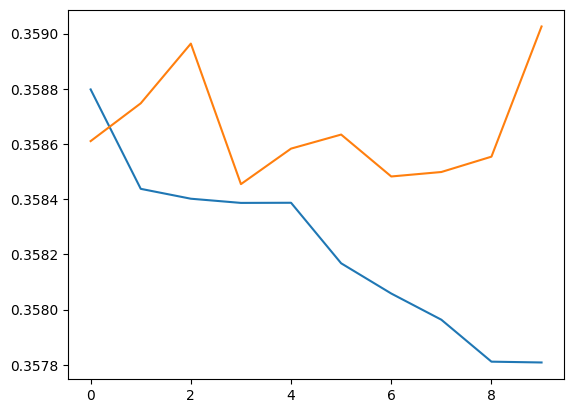

In [107]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

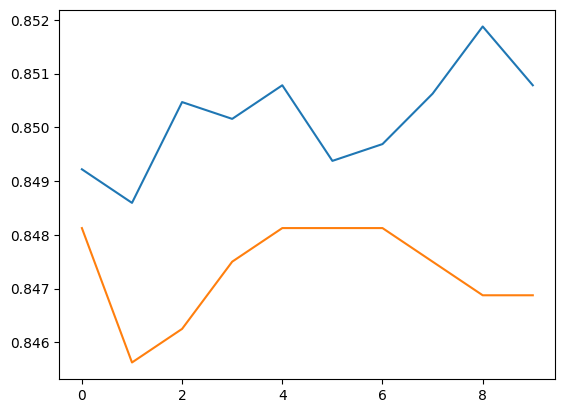

In [109]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])